# Project 3 — Multimodal BEV Perception

**Experiment ID:** P3-2  
**Architecture:** RGB Baseline      
**Task:** BEV Occupancy Prediction  
**Dataset:** nuScenes-mini

This notebook establishes the first learning baseline for Project 3.

Using only front-camera RGB imagery, the model learns to predict a
Bird's-Eye-View (BEV) occupancy map generated from LiDAR.

The RGB baseline serves as a reference for later LiDAR-only and
multimodal sensor-fusion models.

## Metadata

**Project**

Cross-Domain Multimodal Sensor Fusion for BEV Occupancy Prediction

**Dataset**

NuScenes Mini v1.0

**Input**

- RGB Camera

**Target**

- LiDAR-derived BEV occupancy map

**Objective**

Learn a mapping

```
   RGB Image
      ↓
     CNN
      ↓
 BEV Occupancy Map
```

This baseline establishes the contribution of visual information alone.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
checkpoints	data	    notebooks  reports	src
colab_packages	deployment  nuscenes   scripts


In [ ]:
import os, sys
# --- System ---
sys.path.append('/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/colab_packages')


In [ ]:

import sys, os, importlib
# Make sure your src/ directory is visible to Python
project_root = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f" Added to sys.path: {src_path}")

# Clear any stale caches
importlib.invalidate_caches()

 Added to sys.path: /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/src


## 1. Environment Setup

Configure the project environment, import required libraries,
and initialize random seeds for reproducibility.

In [ ]:
import os, sys, torch, random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm
import h5py

# Add project src to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Local imports
from src.dataset_utils import RGBBEVDataset
from src.model.rgb_baseline import RGBBaselineModel
from src.losses import HybridLoss
from src.preprocess_utils import preprocess_rgb  # for sanity viz if needed

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Using device:", device)


 Using device: cuda


## 2. Dataset Loading

Load the preprocessed HDF5 dataset generated during Phase 1.

Each sample contains

- RGB image
- BEV occupancy map
- IMU feature vector

Only the RGB image and BEV target are used in this baseline.

Found 323 samples.


Sample index: 318
RGB shape: torch.Size([3, 256, 256]) | BEV shape: torch.Size([1, 200, 200]) | IMU shape: torch.Size([10, 6])


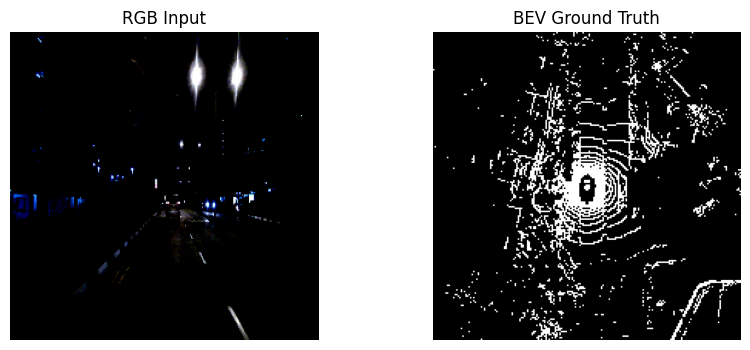

In [ ]:
# Path to moving-scene dataset
data_dir = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed_moving"
assert os.path.exists(data_dir), f" Folder not found: {data_dir}"

# Collect .h5 files
h5_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".h5")])
print(f"Found {len(h5_files)} samples.")

# Initialize dataset
dataset = RGBBEVDataset(h5_files)

# Inspect one random sample
idx = random.randint(0, len(dataset) - 1)
rgb, bev, imu = dataset[idx]

print(f"Sample index: {idx}")
print(f"RGB shape: {rgb.shape} | BEV shape: {bev.shape} | IMU shape: {imu.shape}")

# Sanity check visualization
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(np.transpose(rgb.numpy(), (1, 2, 0)))
plt.title("RGB Input"); plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bev[0].numpy(), cmap="gray")
plt.title("BEV Ground Truth"); plt.axis("off")
plt.show()


## 3. Dataset Splitting

Partition the dataset into training and validation subsets.

PyTorch DataLoaders provide:

- mini-batch loading
- data shuffling
- efficient iteration during training

In [ ]:
from torch.utils.data import DataLoader, random_split

# Reuse dataset from previous cell
total_samples = len(dataset)
val_ratio = 0.2
val_size = int(total_samples * val_ratio)
train_size = total_samples - val_size

train_set, val_set = random_split(dataset, [train_size, val_size])

print(f"Train: {len(train_set)} | Val: {len(val_set)}")

# DataLoaders
BATCH_SIZE = 8
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Sanity check: one batch
rgb_batch, bev_batch, imu_batch = next(iter(train_loader))
print(f"RGB batch: {rgb_batch.shape} | BEV batch: {bev_batch.shape} | IMU batch: {imu_batch.shape}")


Train: 259 | Val: 64
RGB batch: torch.Size([8, 3, 256, 256]) | BEV batch: torch.Size([8, 1, 200, 200]) | IMU batch: torch.Size([8, 10, 6])


### Architecture

This phase establishes the RGB-only baseline for predicting Bird's-Eye-View
(BEV) occupancy maps from front-camera images.

The model adopts a lightweight encoder-decoder CNN designed for
small-batch training while remaining computationally efficient.

Encoder

RGB Image
    ↓
Conv → GroupNorm → ReLU → MaxPool
    ↓
Conv → GroupNorm → ReLU → MaxPool
    ↓
Conv → GroupNorm → ReLU → MaxPool

Decoder

Upsample → Conv → GroupNorm → ReLU
    ↓
Upsample → Conv → GroupNorm → ReLU
    ↓
Upsample → Conv → GroupNorm → ReLU
    ↓
1×1 Conv
    ↓
BEV Occupancy Logits

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.model.rgb_baseline import RGBBaselineModel


# ---------------------------------------------------
# Initialize RGB baseline model
# ---------------------------------------------------
model = RGBBaselineModel().to(device)

# print(model)


# ---------------------------------------------------
# Optimizer & Loss
# ---------------------------------------------------
loss_fn = HybridLoss(bce_weight=0.7)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
)


# ---------------------------------------------------
# Model Summary
# ---------------------------------------------------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("RGB Baseline")
print("-" * 12)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

RGB Baseline
------------
Total parameters     : 190,481
Trainable parameters : 190,481


## 5. Model Training

Train the RGB baseline using supervised learning.

### Training Objective

The network predicts **BEV occupancy logits** rather than probabilities.

Training minimizes a hybrid loss consisting of:

- **BCEWithLogitsLoss**
- **Dice Loss**

The sigmoid activation is intentionally omitted from the model and is applied only during Dice-loss computation and inference.

### Training Procedure

For each epoch:

1. Forward pass (predict BEV occupancy logits)
2. Compute Hybrid Loss (BCEWithLogitsLoss + Dice Loss)
3. Backpropagation
4. Parameter update
5. Validation
6. Save the best-performing checkpoint

In [ ]:
import time
import torch.nn.functional as F
import numpy as np

def soft_iou(pred, target, smooth=1e-6):
    """Compute soft IoU between predicted and target BEV maps."""
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean().item()


t0 = time.time()

EPOCHS = 40
best_val_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for rgb, bev, imu in train_loader:
        rgb, bev = rgb.to(device), bev.to(device)
        pred = model(rgb)

        #  Resize ground truth BEV to match model output size
        if bev.shape[-1] != pred.shape[-1]:
            bev = F.interpolate(bev, size=pred.shape[-2:], mode='bilinear', align_corners=False)

        loss = loss_fn(pred, bev)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # ---- Validation ----
    model.eval()
    val_loss, val_iou = 0.0, 0.0
    with torch.no_grad():
        for rgb, bev, imu in val_loader:
            rgb, bev = rgb.to(device), bev.to(device)
            pred = model(rgb)

            #  Resize ground truth BEV to match model output
            if bev.shape[-1] != pred.shape[-1]:
                bev = F.interpolate(bev, size=pred.shape[-2:], mode='bilinear', align_corners=False)

            val_loss += loss_fn(pred, bev).item()
            val_iou += soft_iou(pred, bev)

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val IoU: {val_iou:.4f}")

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        os.makedirs("checkpoints", exist_ok=True)
        torch.save(model.state_dict(), "checkpoints/rgb_baseline_best.pth")

t1 = time.time()

print(f"\n Training complete. Best Val IoU: {best_val_iou:.4f}")
print(f" Total training time: {(t1 - t0)/60:.2f} minutes")


Epoch 1/40 | Train Loss: 0.6841 | Val Loss: 0.6555 | Val IoU: 0.0000
Epoch 2/40 | Train Loss: 0.6435 | Val Loss: 0.6261 | Val IoU: 0.0000
Epoch 3/40 | Train Loss: 0.6231 | Val Loss: 0.6097 | Val IoU: 0.0000
Epoch 4/40 | Train Loss: 0.6087 | Val Loss: 0.5983 | Val IoU: 0.0000
Epoch 5/40 | Train Loss: 0.5991 | Val Loss: 0.5892 | Val IoU: 0.0000
Epoch 6/40 | Train Loss: 0.5934 | Val Loss: 0.5833 | Val IoU: 0.0026
Epoch 7/40 | Train Loss: 0.5823 | Val Loss: 0.5714 | Val IoU: 0.1329
Epoch 8/40 | Train Loss: 0.5732 | Val Loss: 0.5654 | Val IoU: 0.1520
Epoch 9/40 | Train Loss: 0.5705 | Val Loss: 0.5697 | Val IoU: 0.1310
Epoch 10/40 | Train Loss: 0.5637 | Val Loss: 0.5562 | Val IoU: 0.1621
Epoch 11/40 | Train Loss: 0.5550 | Val Loss: 0.5680 | Val IoU: 0.1510
Epoch 12/40 | Train Loss: 0.5524 | Val Loss: 0.5563 | Val IoU: 0.1877
Epoch 13/40 | Train Loss: 0.5555 | Val Loss: 0.5505 | Val IoU: 0.1863
Epoch 14/40 | Train Loss: 0.5428 | Val Loss: 0.5532 | Val IoU: 0.1746
Epoch 15/40 | Train Loss: 0.5

## 6. Quantitative Evaluation



### Evaluation Pipeline

The trained RGB baseline is evaluated using the standalone evaluation
script. The script computes IoU, Precision, Recall and F1, exports
Markdown/CSV reports, and updates the project leaderboard.

In [ ]:
# ============================================================
# Quantitative Evaluation
#
# Evaluate the trained RGB Baseline model on the validation
# dataset using standard binary occupancy segmentation metrics.
#
# Metrics
#   • Mean IoU
#   • Mean Precision
#   • Mean Recall
#   • Mean F1 Score
#
# The evaluation summary is automatically written to the
# project leaderboard and experiment reports.
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F
import time

from src.report_utils import save_report


evaluation_start = time.time()

# ---------------------------------------------------
# Metric computation
# ---------------------------------------------------
def compute_metrics(
    pred,
    target,
    thresh=0.5,
):
    """
    Compute binary segmentation metrics.

    Parameters
    ----------
    pred : ndarray
        Predicted occupancy probabilities.

    target : ndarray
        Ground-truth occupancy map.

    thresh : float
        Threshold for binarizing predictions.

    Returns
    -------
    tuple
        (
            IoU,
            Precision,
            Recall,
            F1,
        )
    """

    pred_bin = (
        pred > thresh
    ).astype(np.uint8)

    target_bin = (
        target > 0.5
    ).astype(np.uint8)

    tp = np.logical_and(
        pred_bin == 1,
        target_bin == 1,
    ).sum()

    fp = np.logical_and(
        pred_bin == 1,
        target_bin == 0,
    ).sum()

    fn = np.logical_and(
        pred_bin == 0,
        target_bin == 1,
    ).sum()

    precision = tp / (tp + fp + 1e-6)

    recall = tp / (tp + fn + 1e-6)

    f1 = (
        2
        * precision
        * recall
        / (precision + recall + 1e-6)
    )

    intersection = np.logical_and(
        pred_bin,
        target_bin,
    ).sum()

    union = np.logical_or(
        pred_bin,
        target_bin,
    ).sum()

    iou = intersection / (union + 1e-6)

    return (
        iou,
        precision,
        recall,
        f1,
    )


# ---------------------------------------------------
# Load best checkpoint
# ---------------------------------------------------
checkpoint_path = (
    "checkpoints/rgb_baseline_best.pth"
)

print(
    f"Loading checkpoint → {checkpoint_path}"
)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Evaluate validation set
# ---------------------------------------------------
iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():

    for rgb, bev, _ in val_loader:

        rgb = rgb.to(device)

        bev = bev.to(device)

        logits = model(
            rgb,
        )

        if logits.shape[-2:] != bev.shape[-2:]:

            logits = F.interpolate(
                logits,
                size=bev.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        probs = torch.sigmoid(
            logits
        )

        pred_np = (
            probs.cpu().numpy()
        )

        gt_np = (
            bev.cpu().numpy()
        )

        for pred, target in zip(
            pred_np,
            gt_np,
        ):

            (
                iou,
                precision,
                recall,
                f1,
            ) = compute_metrics(
                pred[0],
                target[0],
            )

            iou_scores.append(
                iou
            )

            precision_scores.append(
                precision
            )

            recall_scores.append(
                recall
            )

            f1_scores.append(
                f1
            )


# ---------------------------------------------------
# Aggregate results
# ---------------------------------------------------
summary_dict = {

    "Mean IoU":
        np.mean(iou_scores),

    "Mean Precision":
        np.mean(precision_scores),

    "Mean Recall":
        np.mean(recall_scores),

    "Mean F1":
        np.mean(f1_scores),
}


print("\nValidation Performance")
print("----------------------")

for metric, value in summary_dict.items():

    print(
        f"{metric:<17}: {value:.4f}"
    )


# ---------------------------------------------------
# Save experiment report
# ---------------------------------------------------
evaluation_end = time.time()

save_report(
    summary_dict,
    model_name="RGB Baseline",
    best_iou=summary_dict["Mean IoU"],
    start_time=evaluation_start,
    end_time=evaluation_end,
    auto_update=True,
)


Loading checkpoint → checkpoints/rgb_baseline_best.pth

Validation Performance
----------------------
Mean IoU         : 0.2909
Mean Precision   : 0.5175
Mean Recall      : 0.4019
Mean F1          : 0.4479
 Markdown report saved → reports/rgb_baseline_summary.md
 CSV report saved → reports/rgb_baseline_summary.csv
 Leaderboard saved → reports/leaderboard.csv
️ Markdown summary → reports/leaderboard.md
 Leaderboard plot saved → reports/leaderboard.png


('reports/rgb_baseline_summary.md', 'reports/rgb_baseline_summary.csv')

## 7. Qualitative Evaluation

### Evaluation Pipeline

The trained RGB baseline is evaluated on the validation dataset.

The evaluation script automatically computes:

- Mean IoU
- Precision
- Recall
- F1 Score

The results are exported as Markdown and CSV reports and are
automatically incorporated into the project leaderboard.

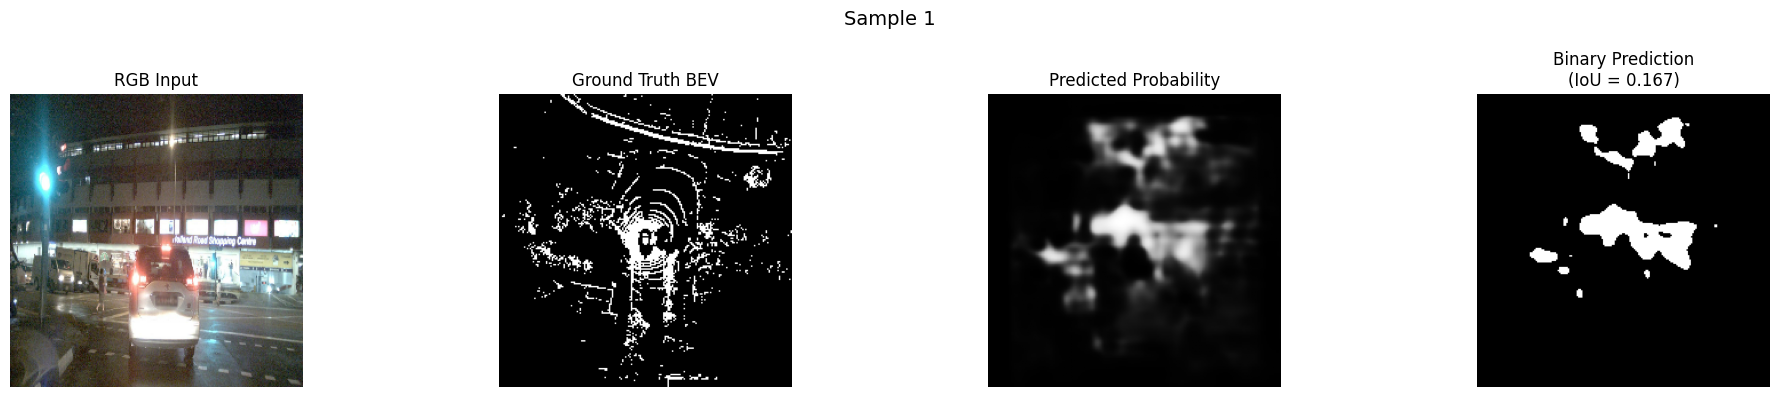

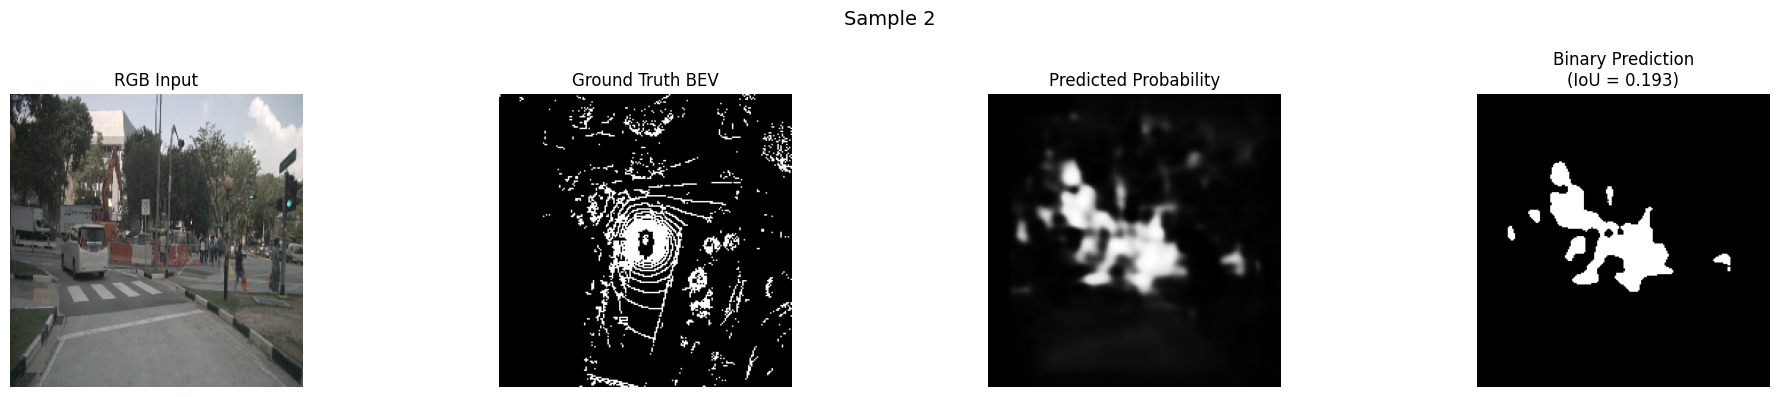

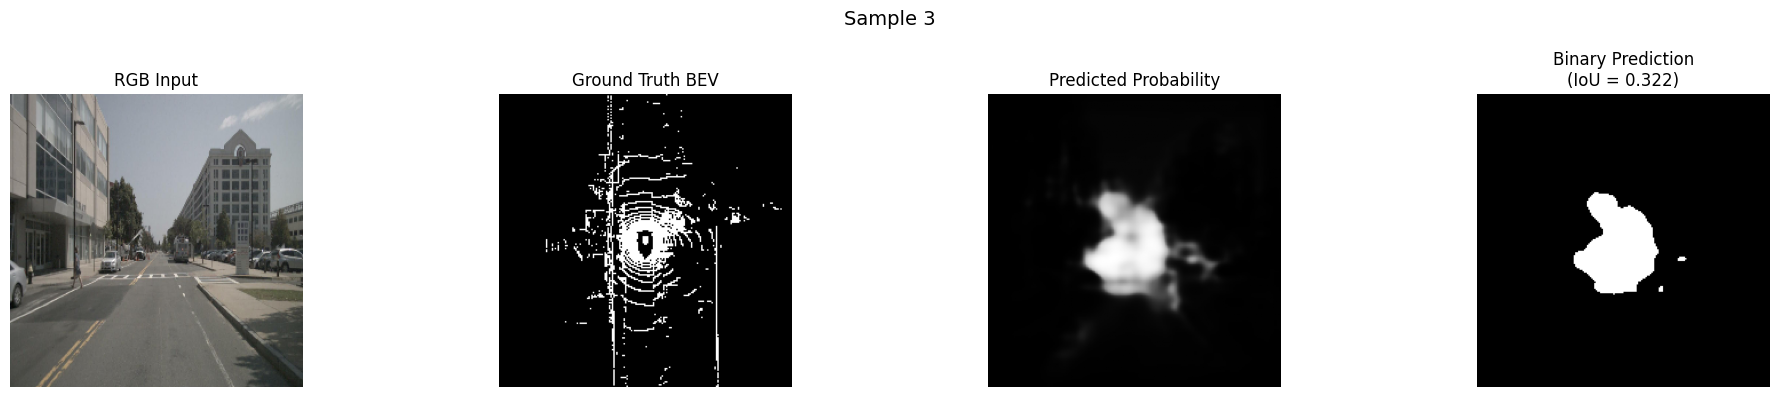

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ---------------------------------------------------
# Load the best-performing checkpoint
# ---------------------------------------------------
ckpt_path = "checkpoints/rgb_baseline_best.pth"
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

# ---------------------------------------------------
# Randomly select validation samples
# ---------------------------------------------------
n_show = 3
indices = random.sample(range(len(val_set)), n_show)

for i, idx in enumerate(indices):

    rgb, bev, imu = val_set[idx]

    rgb = rgb.unsqueeze(0).to(device)
    bev = bev.unsqueeze(0).to(device)

    with torch.no_grad():

        # ---------------------------------------------------
        # Run inference
        # ---------------------------------------------------
        logits = model(rgb)

        # ---------------------------------------------------
        # Convert logits to occupancy probabilities
        # ---------------------------------------------------
        pred = torch.sigmoid(logits)

        # ---------------------------------------------------
        # Resize prediction if necessary
        # ---------------------------------------------------
        if pred.shape[-2:] != bev.shape[-2:]:
            pred = F.interpolate(
                pred,
                size=bev.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        # ---------------------------------------------------
        # Convert tensors to NumPy arrays
        # ---------------------------------------------------
        pred_np = pred.squeeze().cpu().numpy()
        bev_np = bev.squeeze().cpu().numpy()

        # Undo RGB normalization for visualization
        rgb_np = np.transpose(
            rgb.squeeze().cpu().numpy(),
            (1, 2, 0),
        )
        rgb_np = ((rgb_np + 1.0) / 2.0).clip(0, 1)

        # ---------------------------------------------------
        # Threshold probability map
        # ---------------------------------------------------
        pred_bin = (pred_np > 0.5).astype(np.float32)

        # ---------------------------------------------------
        # Compute IoU
        # ---------------------------------------------------
        inter = (pred_bin * bev_np).sum()
        union = pred_bin.sum() + bev_np.sum() - inter
        iou = inter / (union + 1e-6)

    # ---------------------------------------------------
    # Visualize RGB input, ground truth, predicted
    # probability map, and binary occupancy map.
    # ---------------------------------------------------
    fig, axs = plt.subplots(1, 4, figsize=(20, 4))

    axs[0].imshow(rgb_np)
    axs[0].set_title("RGB Input")
    axs[0].axis("off")

    axs[1].imshow(bev_np, cmap="gray")
    axs[1].set_title("Ground Truth BEV")
    axs[1].axis("off")

    axs[2].imshow(pred_np, cmap="gray")
    axs[2].set_title("Predicted Probability")
    axs[2].axis("off")

    axs[3].imshow(pred_bin, cmap="gray")
    axs[3].set_title(f"Binary Prediction\n(IoU = {iou:.3f})")
    axs[3].axis("off")

    plt.suptitle(f"Sample {i + 1}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Phase Summary

### Objectives Achieved

✓ Established the RGB-only baseline for BEV occupancy prediction

✓ Developed a lightweight encoder–decoder CNN with Group Normalization

✓ Trained the network using BCEWithLogitsLoss + Dice Loss

✓ Evaluated performance using IoU, Precision, Recall, and F1

✓ Generated qualitative visualizations including probability and binary occupancy maps

✓ Exported evaluation reports and updated the experiment leaderboard

---

### Output Artifacts

```text
checkpoints/
└── rgb_baseline_best.pth

reports/
├── rgb_baseline_summary.md
├── leaderboard.csv
├── leaderboard.png
└── leaderboard_trends.png
```

The RGB baseline establishes the first quantitative and qualitative
reference for evaluating LiDAR-only, multimodal fusion, and attention-
based perception models in subsequent phases.